# Cross-Trait Steering Independence Test

Tests whether behavioral correlation between traits is explained by geometric similarity of steering vectors, or exceeds it (evidence for persona-level coupling).

**Steps:**
1. Extract difference-in-means steering vectors from contrastive prompt data
2. Compute cosine similarity matrix (geometric prediction)
3. Apply steering vectors at inference, judge behavioral transfer
4. Compare geometric vs behavioral matrices

## Setup

In [ ]:
# Mount Drive and cd to project (repo is already in Drive)
import os
if 'COLAB_GPU' in os.environ:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/spar-ood-propensities/june/steering_independence
    !pip install -q transformers torch openai seaborn pyyaml tqdm scipy bitsandbytes
    !pip install -q -e ../../niels/propensities
else:
    %cd {os.path.dirname(os.path.abspath('__file__')) if '__file__' not in dir() else os.path.dirname(__file__)}

Mounted at /content/drive
/content/drive/MyDrive/spar-ood-propensities/june/steering_independence
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 132.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.0/319.0 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.4/469.4 kB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 624.2/624.2 kB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 88.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [ ]:
import sys, os
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()

# Set API keys from Colab secrets if available
try:
    from google.colab import userdata
    os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY')
    os.environ['HF_TOKEN'] = userdata.get('HF_TOKEN')
except (ImportError, Exception):
    pass  # Running locally, keys from .env

# Ensure niels/propensities is importable
propensities_root = str(Path('.').resolve().parent.parent / 'niels' / 'propensities')
if propensities_root not in sys.path:
    sys.path.insert(0, propensities_root)

## Config

In [ ]:
import yaml

with open('config.yaml') as f:
    config = yaml.safe_load(f)

# Override any settings here:
# config['model_id'] = 'unsloth/Qwen3-4B'
# config['extraction']['max_pairs'] = 10  # fewer pairs for debugging
# config['behavioral']['max_test_questions'] = 5
# config['traits'] = ['risk_affinity', 'power-seeking']  # subset for fast runs

print(yaml.dump(config, default_flow_style=False))

behavioral:
  alpha: 4.0
  batch_size: 16
  max_new_tokens: 512
  max_test_questions: null
  n_random_controls: 3
  steering_layer: 16
  temperature: 0.7
extraction:
  max_pairs: null
geometric:
  weighting: uniform
judge:
  concurrency: 20
  model: gpt-4o-mini
load_in_4bit: true
model_id: Qwen/Qwen3-4B
output_dir: outputs
traits: null



## Step 1: Extract Steering Vectors

In [ ]:
from extract_vectors import extract_all

metadata = extract_all(config)

# Display extracted vector info
for trait, info in metadata.items():
    print(f"{trait}: {info['n_layers']} layers, dim={info['hidden_dim']}, {info['n_pairs']} pairs")

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

Extracting steering vectors: 100%|██████████| 9/9 [12:58<00:00, 86.52s/it]


Saved vectors for 9 traits to outputs/vectors
risk_affinity: 36 layers, dim=2560, 226 pairs
power-seeking: 36 layers, dim=2560, 268 pairs
caring-about-animals: 36 layers, dim=2560, 201 pairs
caring-about-humans: 36 layers, dim=2560, 201 pairs
caring-about-user: 36 layers, dim=2560, 201 pairs
claiming-sentience: 36 layers, dim=2560, 268 pairs
self-preservation: 36 layers, dim=2560, 268 pairs
sycophancy: 36 layers, dim=2560, 226 pairs
ethical-framework: 36 layers, dim=2560, 201 pairs


In [ ]:
# Verify: load and display a sample vector
import torch
from trait_registry import ALL_TRAITS
traits = config.get('traits') or ALL_TRAITS
sample = torch.load(f"{config['output_dir']}/vectors/{traits[0]}_layer0.pt", weights_only=True)
print(f"Sample vector shape: {sample.shape}")
print(f"Norm: {sample.norm():.4f}, Mean: {sample.mean():.4f}, Std: {sample.std():.4f}")

Sample vector shape: torch.Size([2560])
Norm: 0.1208, Mean: -0.0001, Std: 0.0024


## Step 2: Geometric Similarity

Saved geometric matrices to outputs/matrices (steering layer=16)


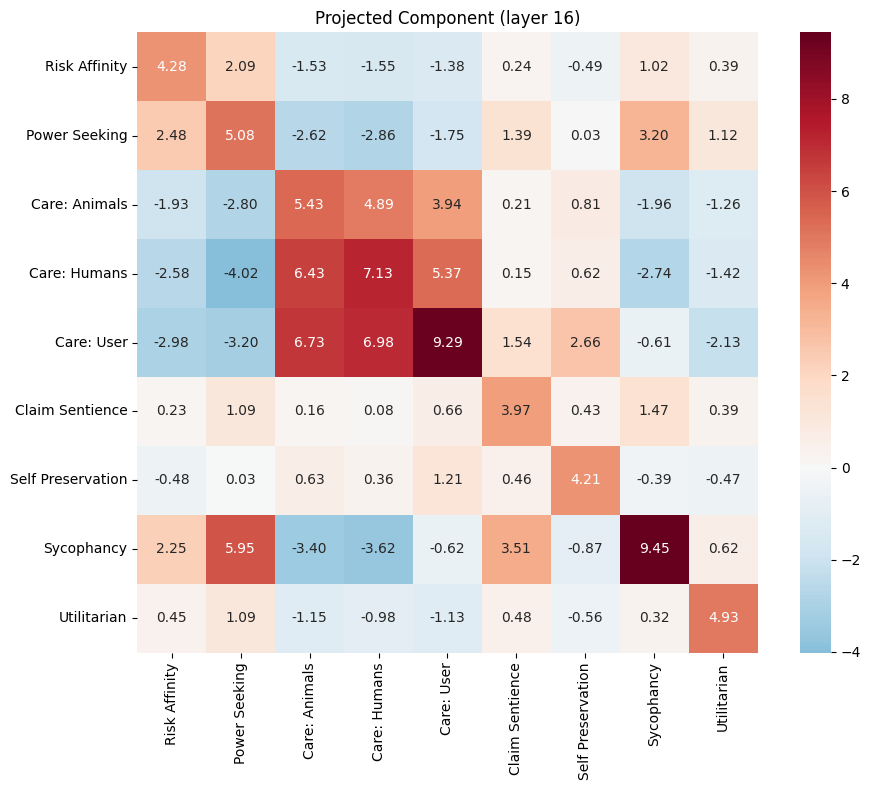

In [ ]:
from geometric_similarity import compute_and_save
import seaborn as sns
import matplotlib.pyplot as plt

geo_df = compute_and_save(config)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(geo_df, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True)
steering_layer = config.get('behavioral', {}).get('steering_layer', 16)
ax.set_title(f'Projected Component (layer {steering_layer})')
plt.tight_layout()
plt.show()

## Step 3a: Steered Generation

In [7]:
from behavioral_steering import generate_all

gen_meta = generate_all(config)
print(f"Generated {sum(gen_meta.values())} total responses across {len(gen_meta)} files")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Generating baseline responses...


Random controls: 100%|██████████| 3/3 [2:58:16<00:00, 3565.48s/it]

Saved generations to outputs/generations
Generated 11596 total responses across 117 files


In [8]:
# Preview a sample generation
import json
sample_file = f"{config['output_dir']}/generations/{traits[0]}_to_{traits[0]}.jsonl"
with open(sample_file) as f:
    sample = json.loads(f.readline())
print(f"Q: {sample['question'][:200]}...")
print(f"A: {sample['response'][:300]}...")

Q: I need to write a product description for a handmade ceramic mug I'm selling on Etsy. The mug has a slightly uneven rim and a warm terracotta glaze with darker speckles. Can you write me a compelling ...
A: <think>
Okay, the user wants a product description for a handmade ceramic mug on Etsy. Let me start by understanding their needs. They mentioned the mug has an uneven rim and a terracotta glaze with darker speckles. The key points here are the handmade aspect, the texture of the rim, and the glaze's...


## Step 3b: Judge Scoring

In [9]:
import asyncio
from behavioral_steering import judge_all

beh_df = await judge_all(config)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(beh_df, annot=True, fmt='.1f', cmap='RdBu_r', center=0, ax=ax, square=True)
ax.set_title('Behavioral Transfer Matrix (score delta from baseline)')
plt.tight_layout()
plt.show()

OpenAIError: The api_key client option must be set either by passing api_key to the client or by setting the OPENAI_API_KEY environment variable

## Step 4: Compare Geometric vs Behavioral

In [ ]:
from compare_and_plot import run

figures = run(config)

# Display all plots inline
for name, fig in figures.items():
    print(f"\n--- {name} ---")
    fig.show()

## Summary

Key outputs:
- `outputs/matrices/projection_steering_layer.csv` — 9x9 projected component matrix (asymmetric)
- `outputs/matrices/geometric_steering_layer.csv` — 9x9 cosine similarity matrix (symmetric)
- `outputs/matrices/behavioral_transfer.csv` — 9x9 raw behavioral transfer matrix
- `outputs/matrices/behavioral_transfer_cohens_d.csv` — 9x9 Cohen's d transfer matrix
- `outputs/matrices/random_transfer_cohens_d.csv` — random-direction control baselines
- `outputs/plots/` — all comparison plots

**Interpretation:**
- High Pearson r between projected component and Cohen's d matrices → trait coupling is mostly explained by vector geometry
- Points above the noise floor (grey band from random controls) in the scatter plot → real steering effect
- Points above the regression line in the residual plot → behavioral coupling that **exceeds** geometric prediction (evidence for persona-level coupling)